In [1]:
import sys
import os
print("Python executable:", sys.executable)
print("Python path:", sys.path)
sys.path.append(os.path.abspath("../../../")) 
import numpy as np
import sys
# Import the fitting module
import inspect
%load_ext autoreload
%autoreload 2
from  csky_gfu_tests.custom_gfu_specs import GFUDataSpecs as custom_gfu
from kingmaker_fork.kingmaker.wrapper import KingSpatialLikelihood
from kingmaker_fork.kingmaker.fitting import KingPSFFitter
import kingmaker_fork.likelihood_analysis.analysis_helpers.fitting_plots as fplt
from kingmaker_fork.likelihood_analysis.utils.performance_evaluation import fitting_score_components
from kingmaker_fork.likelihood_analysis.analysis_helpers.rms_fit_quality import compute_cdf_rms_fit_quality
from  csky_gfu_tests.custom_gfu_specs import coarse_bins_log_energy, coarse_bins_sindec
import csky as cy
timer = cy.timing.Timer()
time = timer.time

Python executable: /home/fkrafft/venvs/icecube-py3v4.4.0/bin/python
Python path: ['/cvmfs/icecube.opensciencegrid.org/py3-v4.4.0/RHEL_9_x86_64_v2/spack/opt/spack/linux-almalinux9-x86_64_v2/gcc-13.3.0/python-3.12.5-kszr5bufasykf3jernzq4bvwqs7jp4pc/lib/python312.zip', '/cvmfs/icecube.opensciencegrid.org/py3-v4.4.0/RHEL_9_x86_64_v2/spack/opt/spack/linux-almalinux9-x86_64_v2/gcc-13.3.0/python-3.12.5-kszr5bufasykf3jernzq4bvwqs7jp4pc/lib/python3.12', '/cvmfs/icecube.opensciencegrid.org/py3-v4.4.0/RHEL_9_x86_64_v2/spack/opt/spack/linux-almalinux9-x86_64_v2/gcc-13.3.0/python-3.12.5-kszr5bufasykf3jernzq4bvwqs7jp4pc/lib/python3.12/lib-dynload', '', '/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages']


Parameters:

In [70]:
signal_event_file: str = '/data/ana/analyses/gfu_online/version-001-p09/IC86_2023_MC.npy'
cache_dir: str = "/data/user/fkrafft/king_fits/likelihood_analysis/IC86_2023_min_counts150_7energy_12_angErr_with_floor_e4.npz" #if already exists -> use cached. else cache it there
weight_field: str = "ow"
angular_cutoff_deg: float = 15
#spectral_indices = [1.8, 2.0, 2.5, 2.7]
spectral_indices = [2.0]
dpsi_nbins = 101
minimum_counts = 150
seed = 0

### Load signal events

In [71]:
signal_events = np.load(signal_event_file)
print(str(len(signal_events)) + ' signal events loaded...')

19517177 signal events loaded...


### Define Bins

We want to use some predefined bins instead of the equal-probability binning, as for full sky analysis we expect physically strong difference in certain regions of events. If we allow our binning method to set the bins based on statistics, it does not account for the physical properties in the region, resulting in poor fitting. 


In [72]:
parametrization_bins = {
    'logE':  np.array([2.5, 3, 3.25, 3.5, 4.25, 5., 6.0]), #  energy bins from 100 GeV to 1 PeV
    'dec': np.arcsin(np.linspace(-1, 1, 10)),  #  10 equal bins in sin_dec
    'angErr': 12
    
}

### Initialize Wrapper 

With cache dir we can load existing fitted parameters

In [73]:
king_wrapper = KingSpatialLikelihood(signal_events = signal_events,
                                        parametrization_bins = parametrization_bins,
                                        spectral_indices= spectral_indices,
                                        cache_name = cache_dir,
                                        dpsi_nbins=dpsi_nbins,
                                        minimum_counts=minimum_counts,
                                        weight_field = "ow",
                                        true_ra_name = "trueRa",
                                        true_dec_name = "trueDec",
                                        true_energy_name = "trueE",
                                        angular_cutoff = np.radians(angular_cutoff_deg),
                                       )

Fitting parameter space...


Fitting King PSF in 648 bins...
  Spectral indices: [2.]
  Binning dimensions: ['logE', 'dec', 'angErr']

  Spectral index γ = 2.00


  5%|▌         | 34/648 [00:01<00:21, 28.32it/s]/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)
/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _unnormalized_cdf
  return super().__call__(*args, **kws)
/home/fkrafft/kingmaker_fork/kingmaker/pdf.py:159: RuntimeWarning: invalid value encountered in multiply
  normalized_cdf[mask] = norm * unnormalized_cdf
100%|██████████| 648/648 [02:23<00:00,  4.51it/s]

    Fitted 502 bins, skipped 146 bins

Fitting complete!


### Take a look at fitting...

Choose gamma index of spectral index you want to visualize

In [74]:
gamma_idx = 0

In [75]:
fit_parameters = king_wrapper.fitted_parameters

In [76]:
king_wrapper.king_pdf

In [77]:
rms =  compute_cdf_rms_fit_quality(fit_parameters= fit_parameters,
                                              king_pdf = king_wrapper.king_pdf,
                                              gamma_idx= gamma_idx,
                                              minimum_counts= minimum_counts)

fit_parameters["fit_rms"] = rms

Look at score first

In [78]:
score_summary = fitting_score_components(fit_parameters, rms, minimum_counts,
                                         alpha = 0.5,
                                         beta = 0.03,
                                         mu = 3.0)
score_summary

{'score': 0.028607952515437747,
 'score_by_gamma': [0.028607952515437747],
 'median_rms': 0.009862983823062145,
 'p90_rms': 0.03777959621851969,
 'frac_skipped': 0.22530864197530864,
 'frac_failed': 0.0}

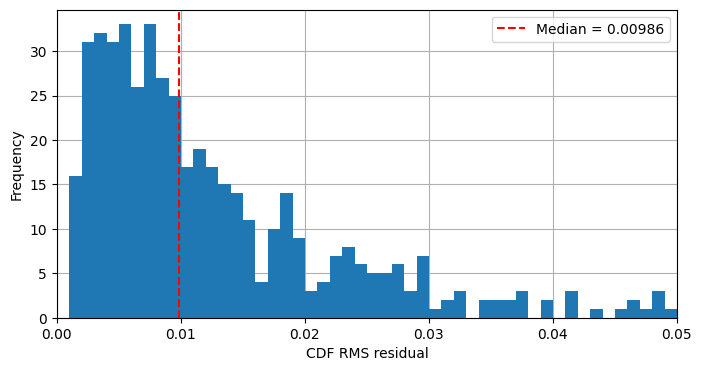

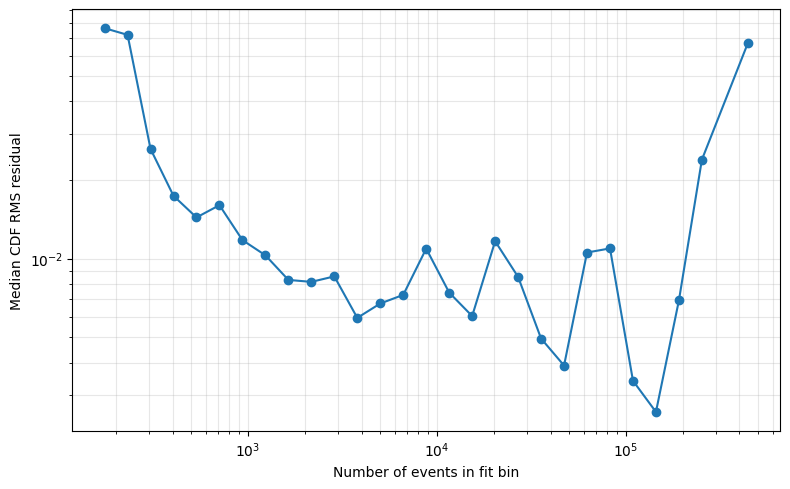

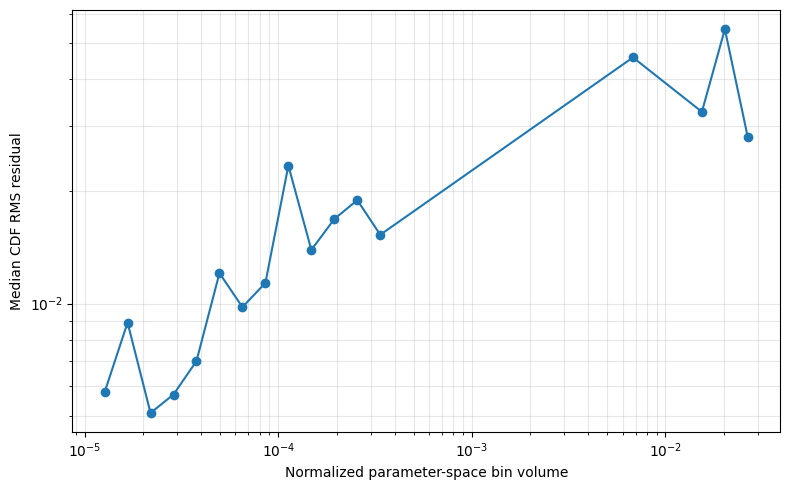

In [79]:
fplt.plot_fit_quality_hist(fit_parameters, gamma_idx, quality_key="fit_rms", range_max=0.05)
fplt.plot_fit_quality_vs_counts(fit_parameters,gamma_idx, quality_key="fit_rms")
fplt.plot_fit_quality_vs_normalized_bin_volume(fit_parameters, gamma_idx, quality_key="fit_rms")

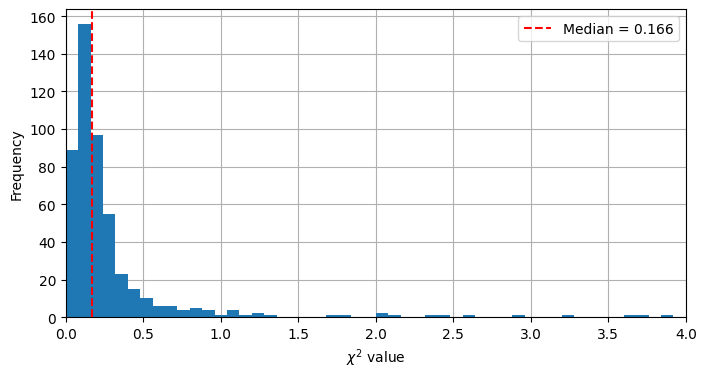

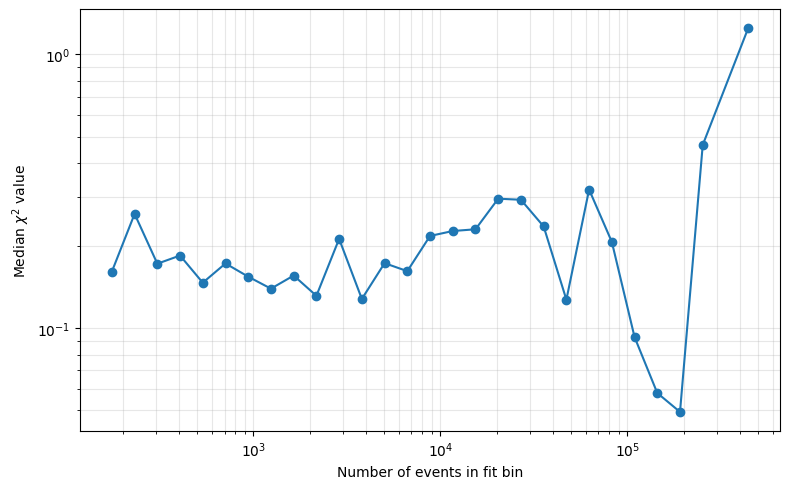

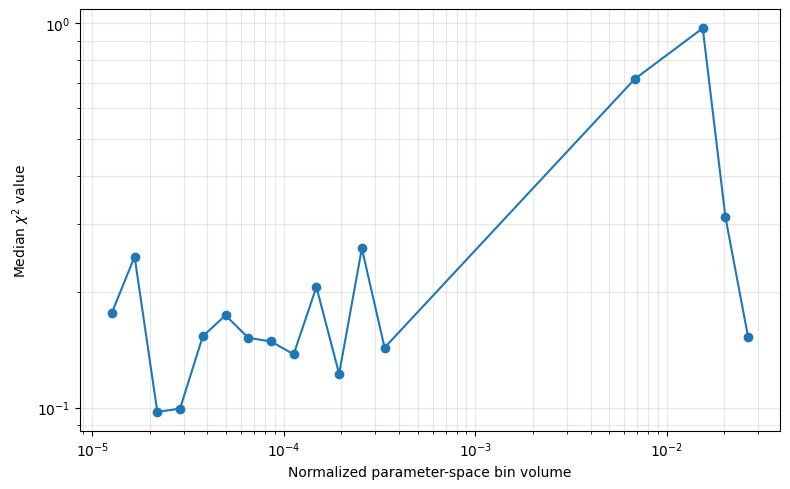

In [80]:
fplt.plot_fit_quality_hist(fit_parameters= fit_parameters, gamma_idx= gamma_idx,range_max = 4)
fplt.plot_fit_quality_vs_counts(fit_parameters= fit_parameters, gamma_idx= gamma_idx)
fplt.plot_fit_quality_vs_normalized_bin_volume(fit_parameters = fit_parameters, gamma_idx= gamma_idx)

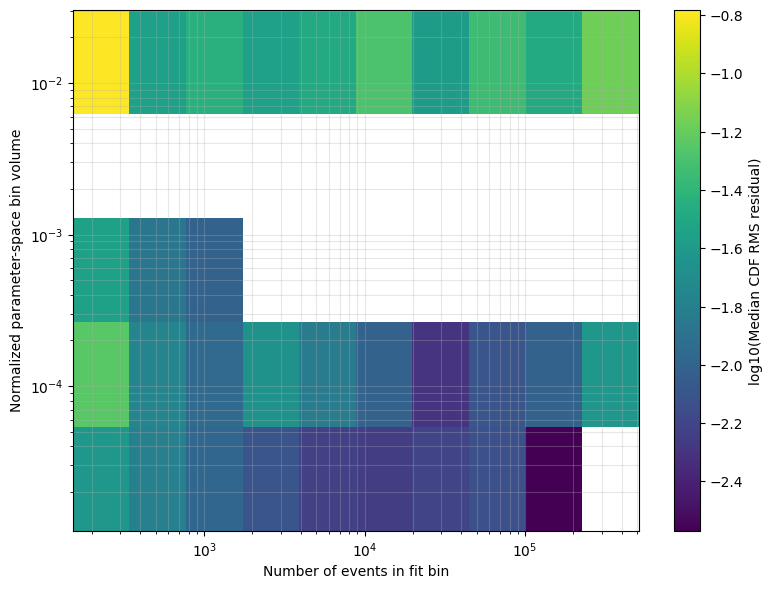

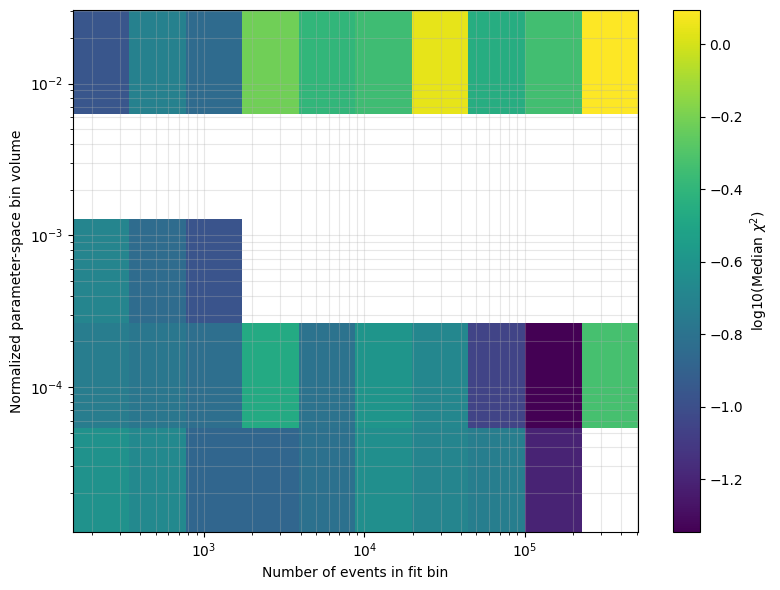

<Axes: xlabel='Number of events in fit bin', ylabel='Normalized parameter-space bin volume'>

In [81]:
fplt.plot_quality_heatmap_counts_vs_volume(fit_parameters, gamma_idx, quality_key="fit_rms", n_count_bins= 10, n_volume_bins= 5)
fplt.plot_quality_heatmap_counts_vs_volume(fit_parameters, gamma_idx, quality_key="fit_quality", n_count_bins= 10, n_volume_bins= 5)

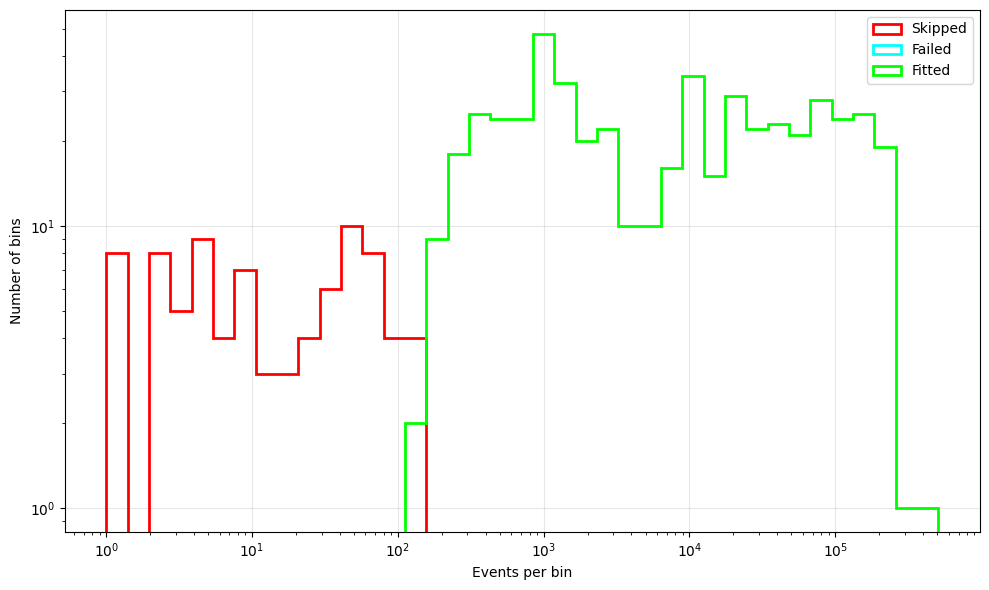

Skipped bins: 146 (22.5%)
Failed bins: 0 (0.0%)
Fitted bins: 502 (77.5%)


In [82]:
bin_success_dict = fplt.plot_event_count_distributions(
    fit_parameters,
    gamma_idx=gamma_idx,
    minimum_counts=minimum_counts,
    log_x=True,
    log_y=True,
)

In [83]:
fit_parameters["parametrization_bins"]

{'logE': array([2.5 , 3.  , 3.25, 3.5 , 4.25, 5.  , 6.  ]),
 'dec': array([-1.57079633, -0.89112251, -0.58903097, -0.33983691, -0.11134101,
         0.11134101,  0.33983691,  0.58903097,  0.89112251,  1.57079633]),
 'angErr': array([8.1895800e-05, 4.7324970e-03, 6.5046097e-03, 8.0900574e-03,
        9.7670322e-03, 1.1653970e-02, 1.3868586e-02, 1.6563224e-02,
        1.9974252e-02, 2.4549715e-02, 3.1311750e-02, 4.3829400e-02,
        1.1385913e+00], dtype=float32)}

In [84]:
hidden_value = np.deg2rad(0.1)
angerr_bins = fit_parameters["parametrization_bins"]["angErr"]

angerr_idx = np.digitize(hidden_value, angerr_bins) - 1
angerr_idx = np.clip(angerr_idx, 0, len(angerr_bins) - 2)

hidden_slices = {"angErr": angerr_idx}

alpha_vals = fit_parameters["alpha"][gamma_idx]
beta_vals = fit_parameters["beta"][gamma_idx]
event_counts = fit_parameters["event_counts"][gamma_idx]
fit_quality_chi2 = fit_parameters["fit_quality"][gamma_idx]
fit_quality_rms = fit_parameters["fit_rms"][gamma_idx]

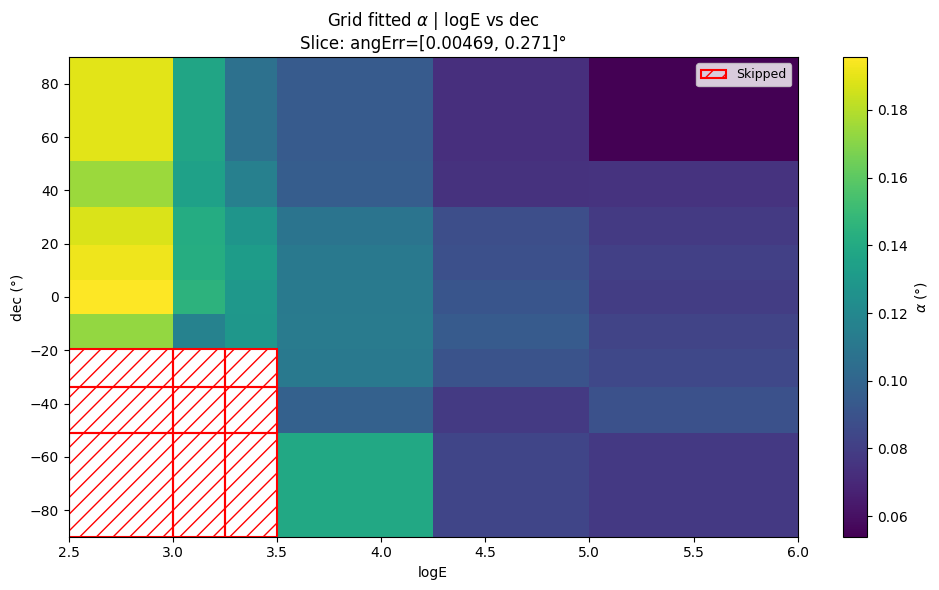

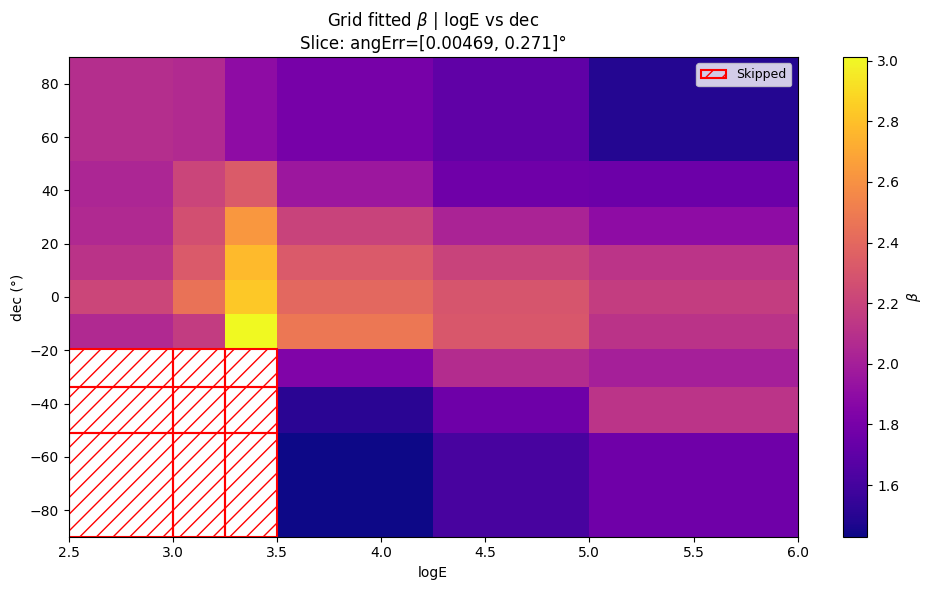

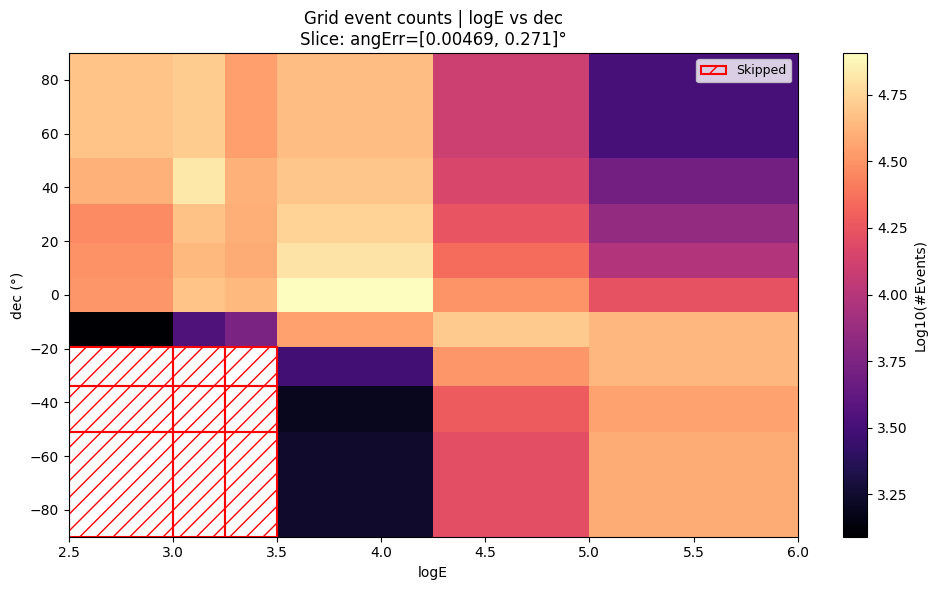

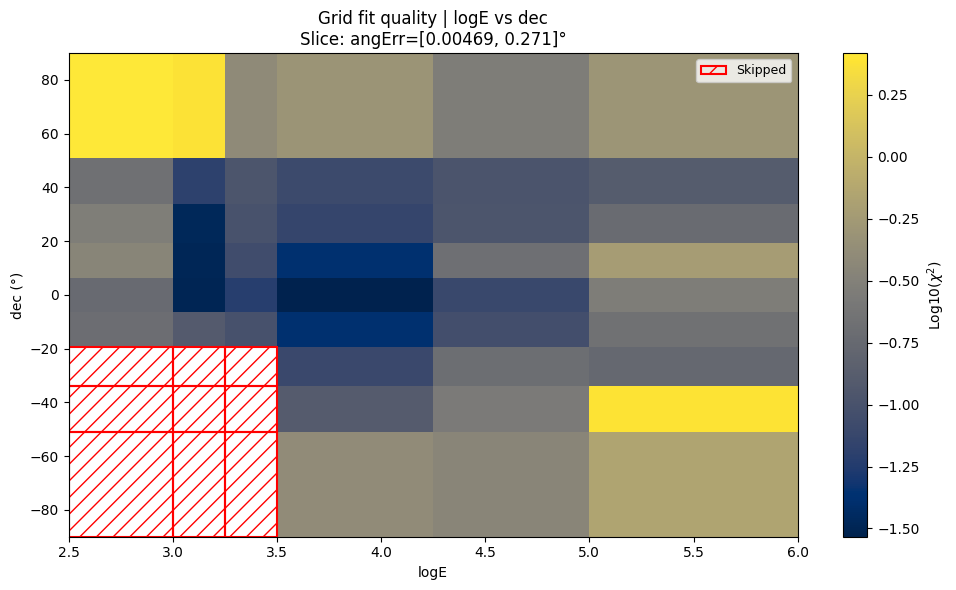

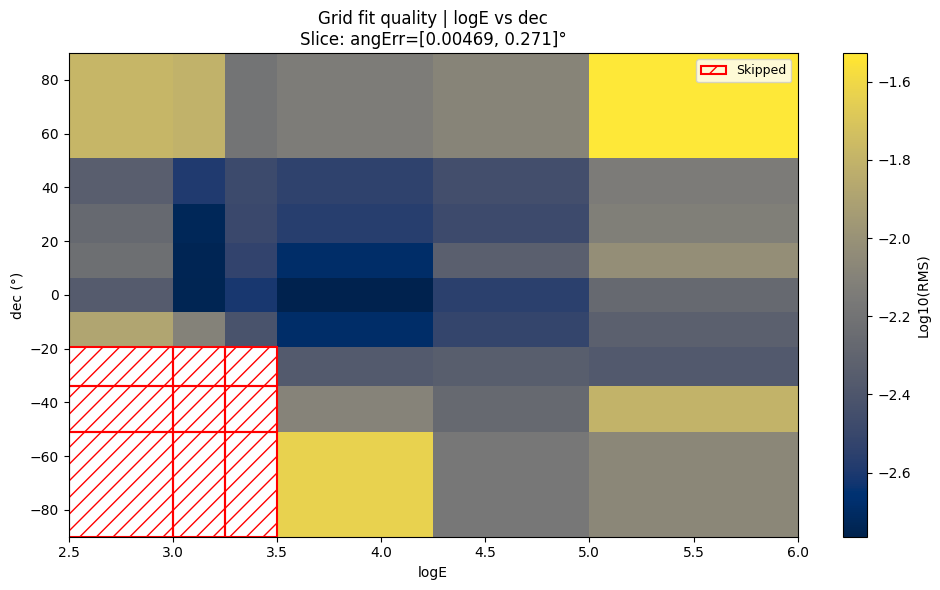

<Axes: title={'center': 'Grid fit quality | logE vs dec\nSlice: angErr=[0.00469, 0.271]°'}, xlabel='logE', ylabel='dec (°)'>

In [85]:
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="dec",
    values=alpha_vals,
    title="Grid fitted $\\alpha$ | logE vs dec",
    cbar_label="$\\alpha$ (°)",
    cmap="viridis",
    y_to_degrees=True,
    value_to_degrees=True,
    hidden_slices=hidden_slices,
)
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="dec",
    values=beta_vals,
    title="Grid fitted $\\beta$ | logE vs dec",
    cbar_label="$\\beta$",
    cmap="plasma",
    y_to_degrees=True,
    hidden_slices=hidden_slices,
)
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    log_values= True,
    y_name="dec",
    values=event_counts,
    title="Grid event counts | logE vs dec",
    cbar_label="Log10(#Events)",
    cmap="magma",
    y_to_degrees=True,
    hidden_slices=hidden_slices,
)
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="dec",
    values=fit_quality_chi2,
    title="Grid fit quality | logE vs dec",
    cbar_label="Log10($\\chi^2$)",
    cmap="cividis",
    y_to_degrees=True,
    log_values=True,
    hidden_slices=hidden_slices,
)
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="dec",
    values=fit_quality_rms,
    title="Grid fit quality | logE vs dec",
    cbar_label="Log10(RMS)",
    cmap="cividis",
    y_to_degrees=True,
    log_values=True,
    hidden_slices=hidden_slices,
)

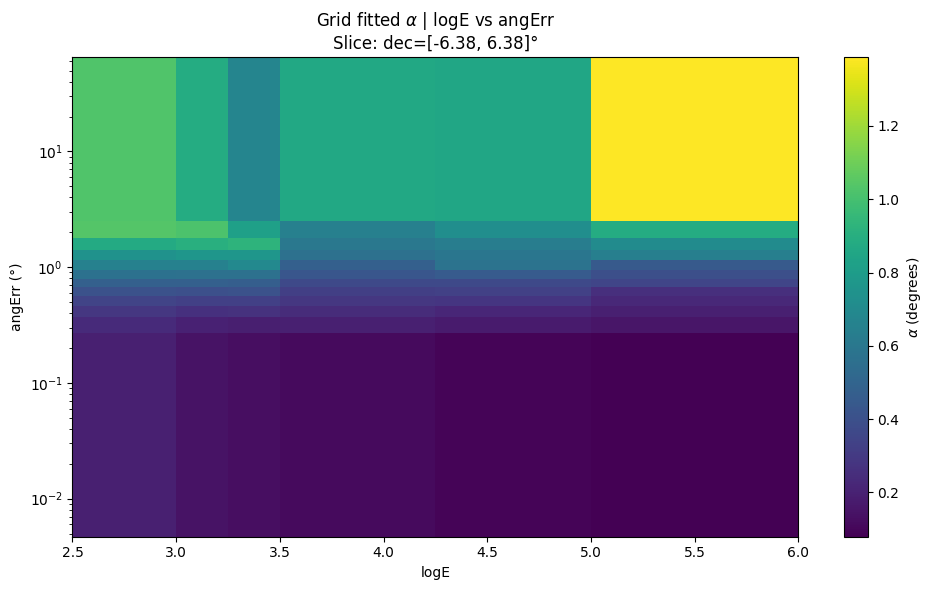

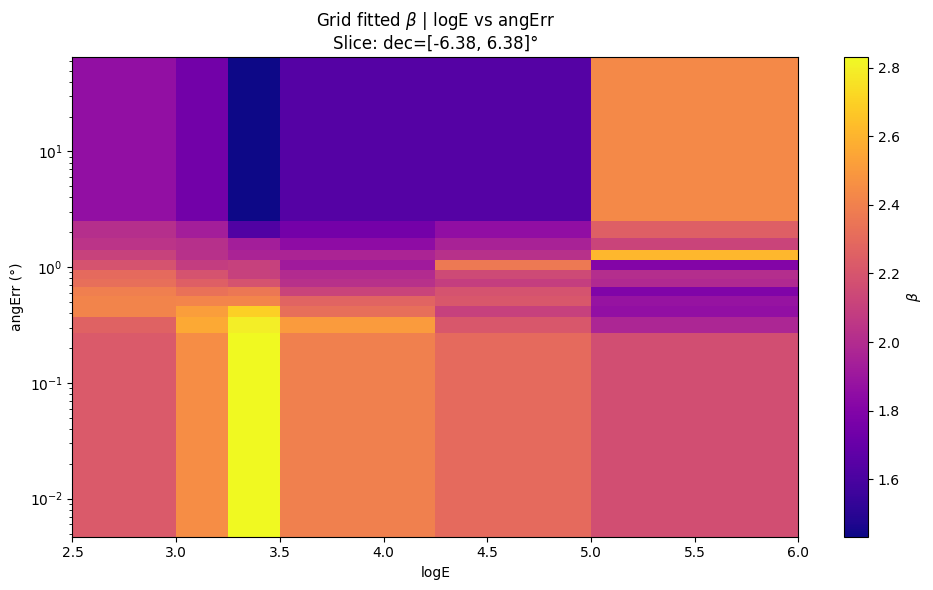

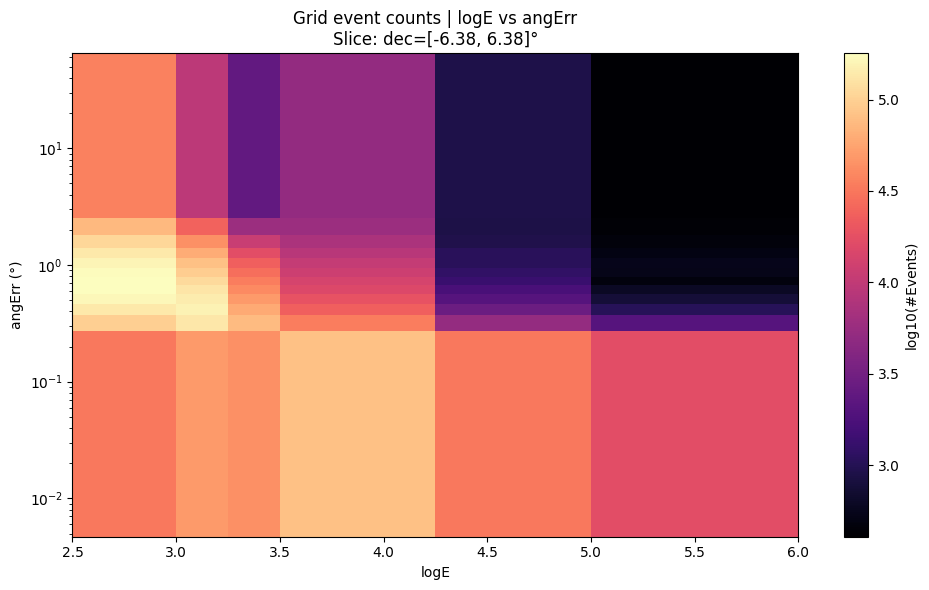

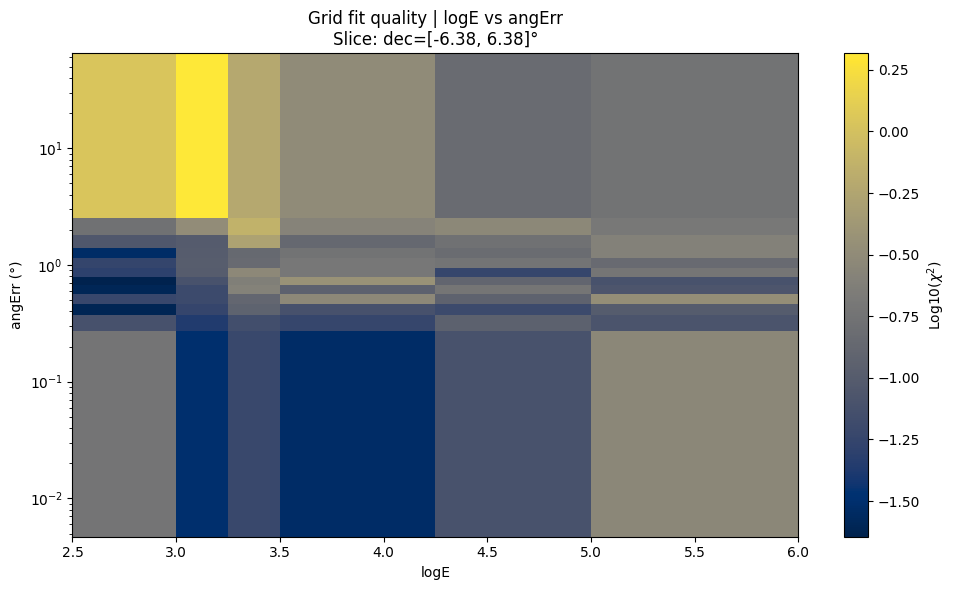

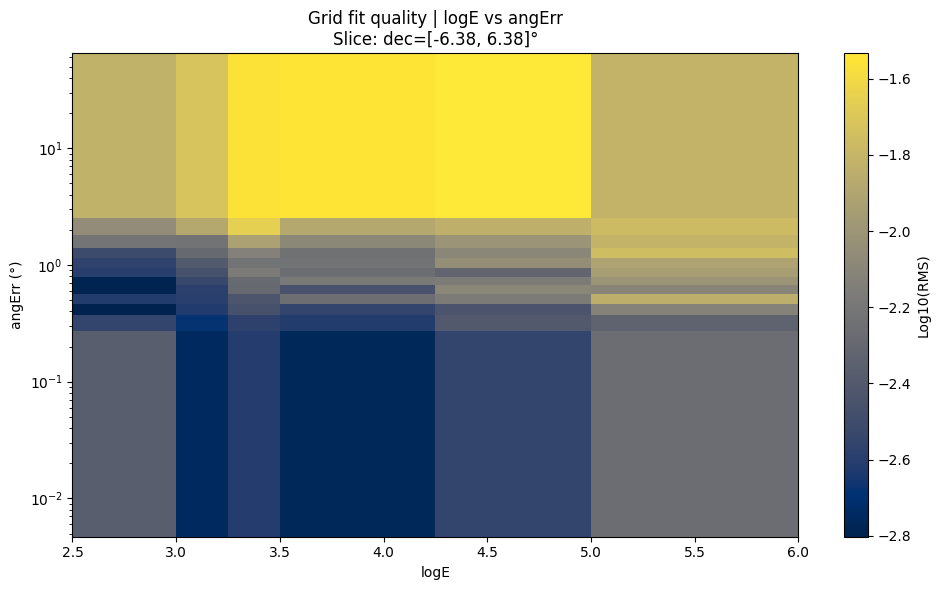

<Axes: title={'center': 'Grid fit quality | logE vs angErr\nSlice: dec=[-6.38, 6.38]°'}, xlabel='logE', ylabel='angErr (°)'>

In [86]:
dec_bins = parametrization_bins["dec"]
dec_idx = len(dec_bins) // 2 - 1

hidden_slices = {"dec": dec_idx}

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="angErr",
    values=alpha_vals,
    title="Grid fitted $\\alpha$ | logE vs angErr",
    cbar_label="$\\alpha$ (degrees)",
    cmap="viridis",
    y_to_degrees=True,
    value_to_degrees=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,
)

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="angErr",
    values=beta_vals,
    title="Grid fitted $\\beta$ | logE vs angErr",
    cbar_label="$\\beta$",
    cmap="plasma",
    y_to_degrees=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,
)

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="angErr",
    values=event_counts,
    title="Grid event counts | logE vs angErr",
    cbar_label="log10(#Events)",
    cmap="magma",
    y_to_degrees=True,
    log_values=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,
)

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="angErr",
    values=fit_quality_chi2,
    title="Grid fit quality | logE vs angErr",
    cbar_label="Log10($\\chi^2$)",
    cmap="cividis",
    y_to_degrees=True,
    log_values=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,
)
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="logE",
    y_name="angErr",
    values=fit_quality_rms,
    title="Grid fit quality | logE vs angErr",
    cbar_label="Log10(RMS)",
    cmap="cividis",
    y_to_degrees=True,
    log_values=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,
)

Found 502 bins with stored fits
Showing best bins:
1: bin=(0, 5, 3), chi2=0.012
2: bin=(0, 6, 2), chi2=0.014
3: bin=(0, 7, 2), chi2=0.018
4: bin=(0, 5, 1), chi2=0.020
5: bin=(0, 5, 2), chi2=0.021
6: bin=(0, 4, 5), chi2=0.023


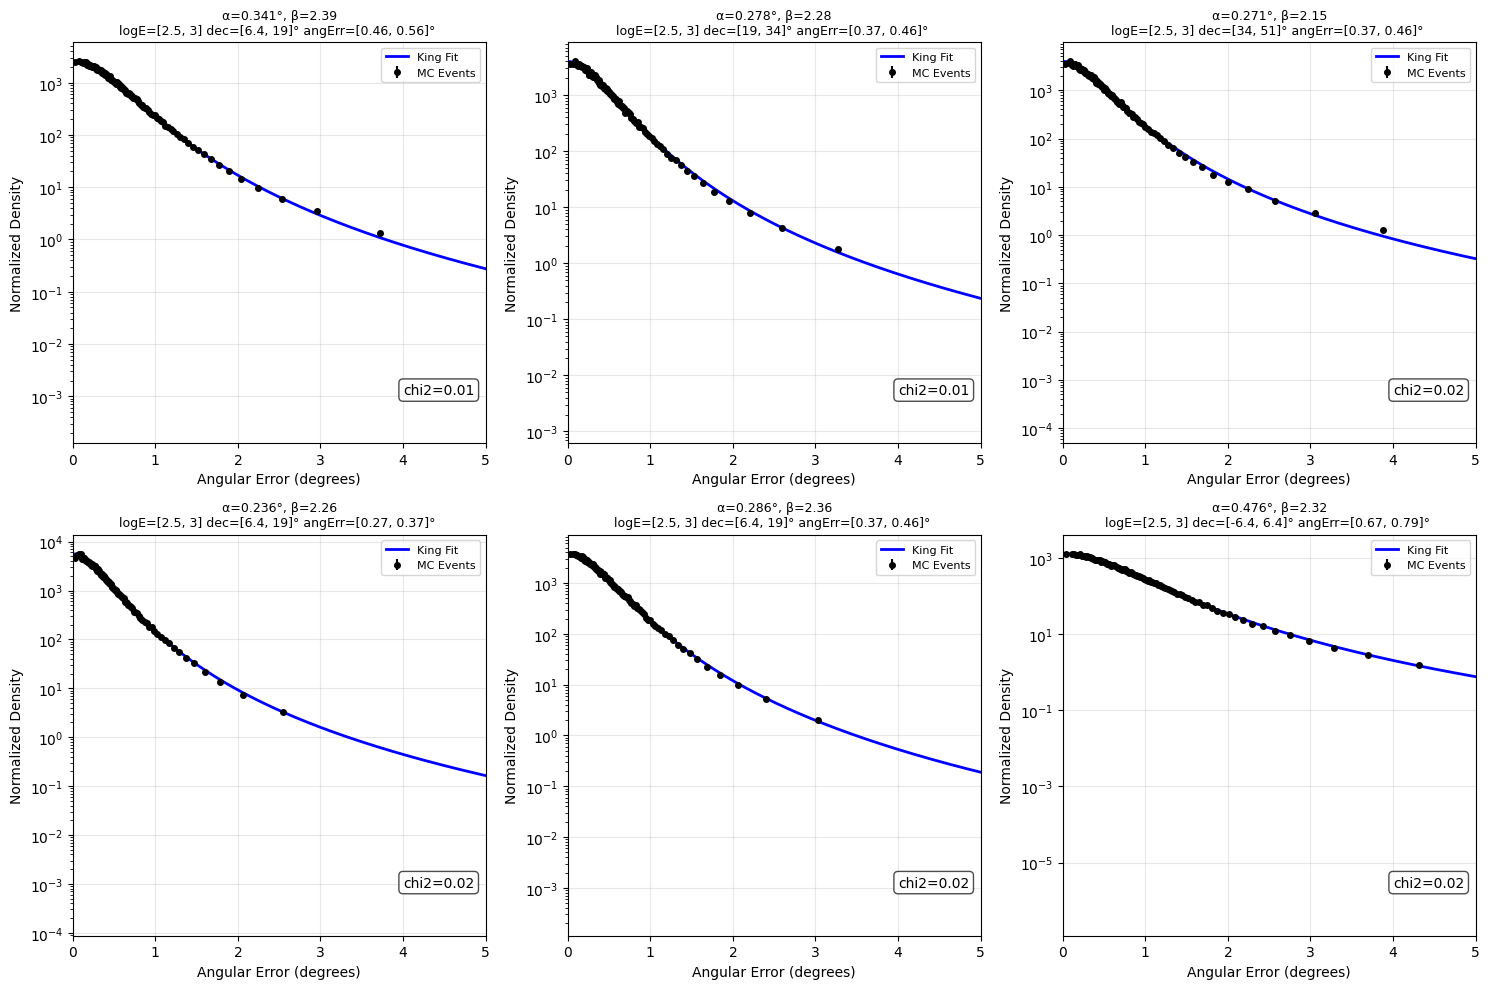

[((0, 5, 3), 0.011679685651500576),
 ((0, 6, 2), 0.014162911220660533),
 ((0, 7, 2), 0.017675374432396418),
 ((0, 5, 1), 0.01968305563240594),
 ((0, 5, 2), 0.021365441607678566),
 ((0, 4, 5), 0.02265898315971579)]

In [87]:
fplt.plot_selected_fit_bins(
    fit_parameters,
    mode="best",
    gamma_idx= gamma_idx,
    n_plots=6,
    minimum_counts=minimum_counts,
)

Found 502 bins with stored fits
Showing worst bins:
1: bin=(1, 8, 4), chi2=12.280
2: bin=(4, 1, 1), chi2=10.432
3: bin=(3, 7, 8), chi2=8.908
4: bin=(3, 5, 8), chi2=8.580
5: bin=(1, 6, 6), chi2=8.386
6: bin=(3, 7, 11), chi2=7.850


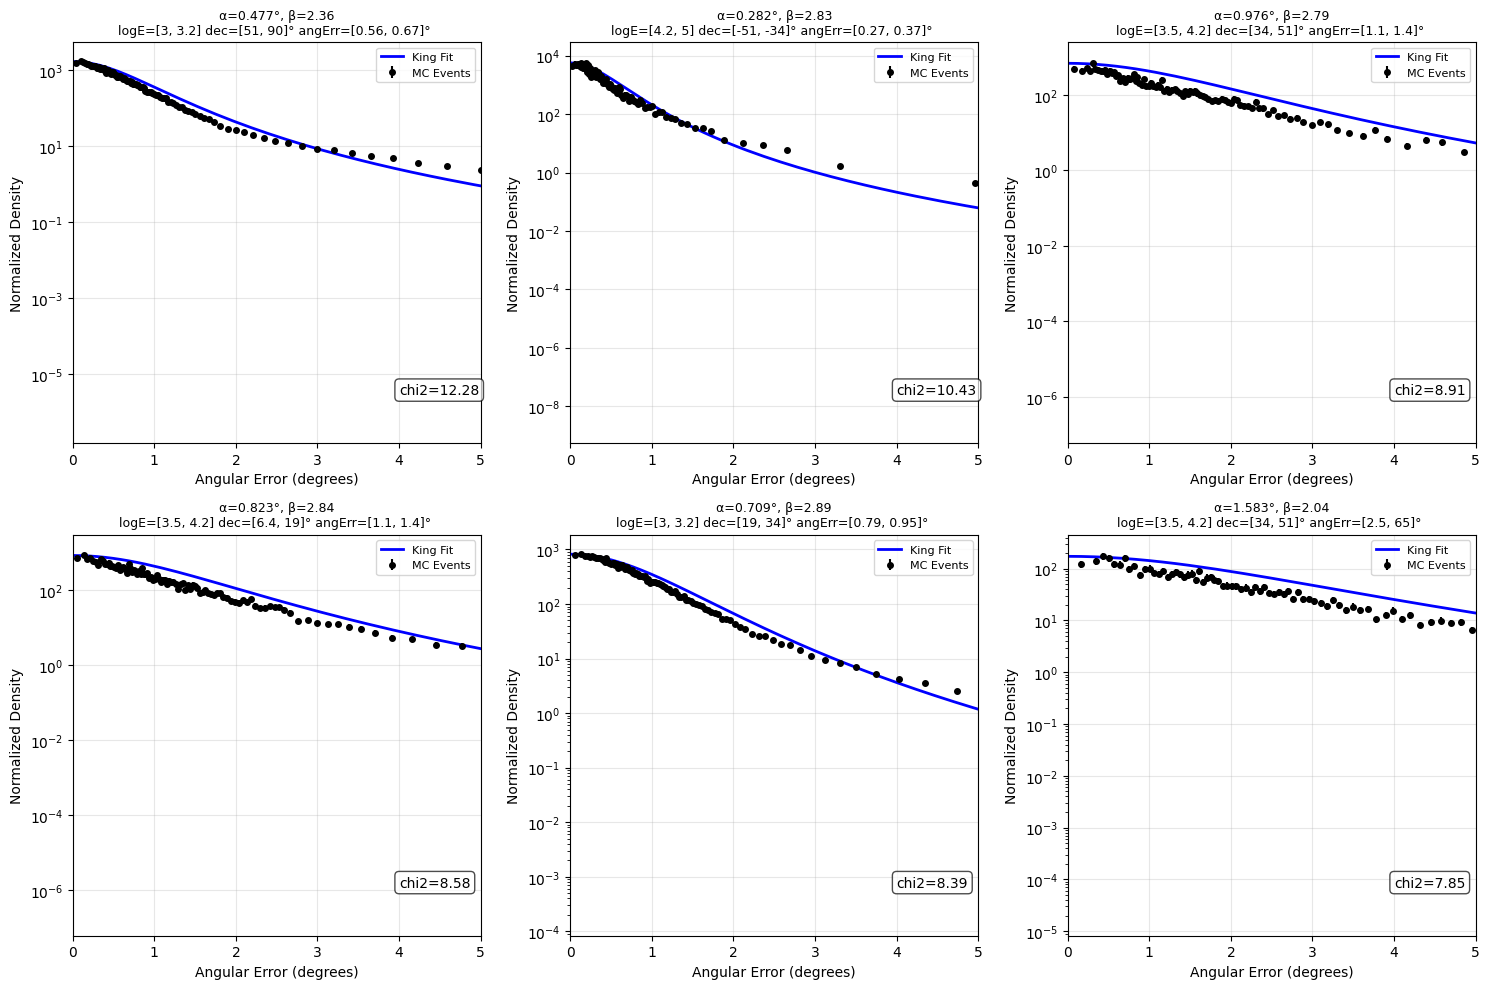

[((1, 8, 4), 12.279978618708345),
 ((4, 1, 1), 10.432205664897198),
 ((3, 7, 8), 8.907797080446308),
 ((3, 5, 8), 8.58010375376044),
 ((1, 6, 6), 8.385903443150466),
 ((3, 7, 11), 7.850006318850542)]

In [88]:
fplt.plot_selected_fit_bins(
    fit_parameters,
    mode="worst",
    gamma_idx=gamma_idx,
    n_plots=6,
    minimum_counts=minimum_counts,
)

Found 502 bins with stored fits
Showing random bins:
1: bin=(4, 3, 4), chi2=0.070
2: bin=(4, 8, 3), chi2=0.056
3: bin=(3, 3, 2), chi2=0.310
4: bin=(5, 3, 1), chi2=0.118
5: bin=(3, 3, 5), chi2=0.131
6: bin=(0, 6, 10), chi2=0.082


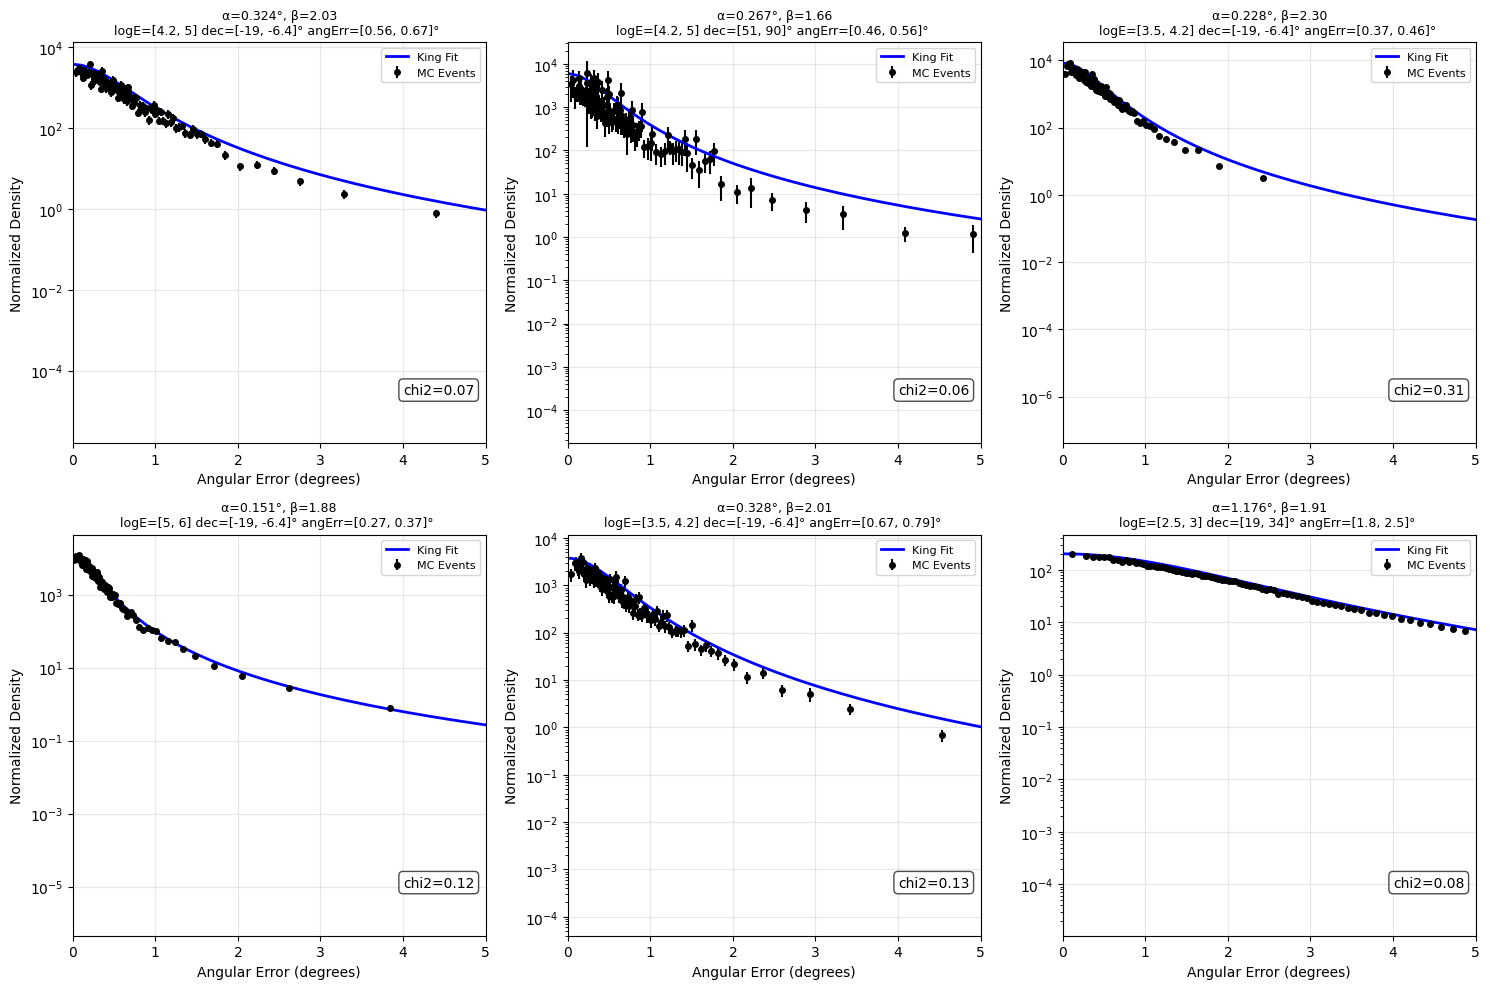

[((4, 3, 4), 0.07009899608160348),
 ((4, 8, 3), 0.055740787622760087),
 ((3, 3, 2), 0.30980674174428385),
 ((5, 3, 1), 0.11794169791394045),
 ((3, 3, 5), 0.13077284079937196),
 ((0, 6, 10), 0.082093505417183)]

In [89]:
fplt.plot_selected_fit_bins(
    fit_parameters,
    mode="random",
    gamma_idx=gamma_idx,
    n_plots=6,
    minimum_counts=minimum_counts,
    random_seed=42,
)

Found 502 bins with stored fits
Showing grid bins:
1: bin=(0, 3, 0), chi2=0.198
2: bin=(1, 3, 1), chi2=0.172
3: bin=(1, 3, 3), chi2=0.297
4: bin=(2, 3, 4), chi2=0.113
5: bin=(2, 4, 6), chi2=0.296
6: bin=(3, 5, 7), chi2=0.177
7: bin=(4, 6, 8), chi2=0.090
8: bin=(4, 7, 10), chi2=0.208
9: bin=(5, 8, 11), chi2=0.290


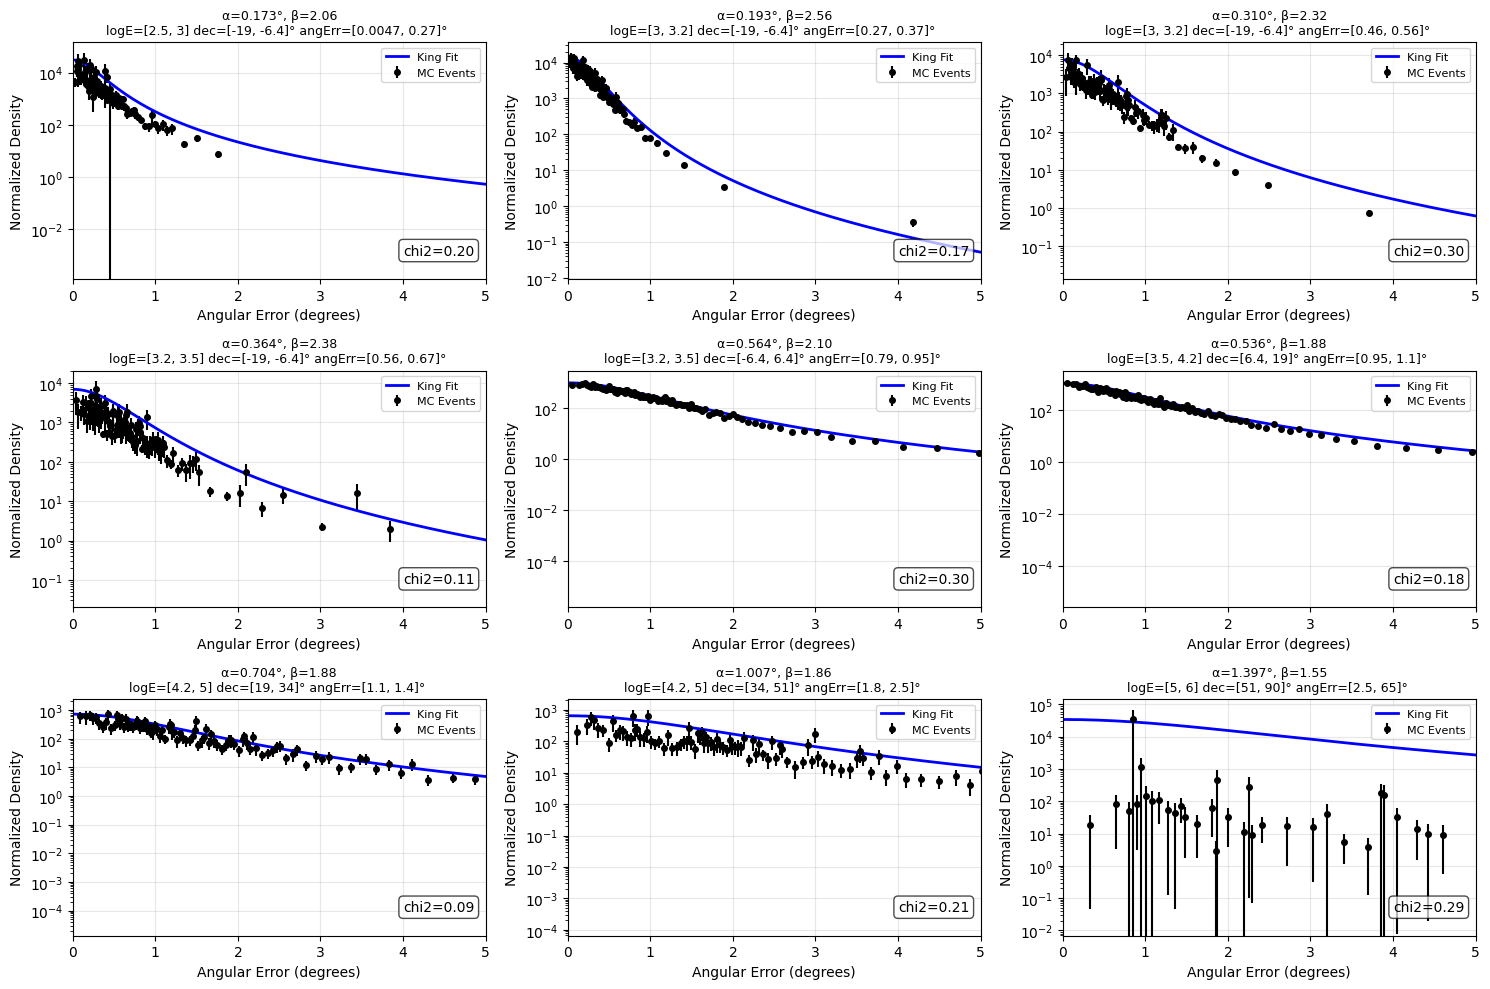

[((0, 3, 0), 0.19793297499486004),
 ((1, 3, 1), 0.17249077314861705),
 ((1, 3, 3), 0.29739162880504744),
 ((2, 3, 4), 0.11315169954665034),
 ((2, 4, 6), 0.2959680814998726),
 ((3, 5, 7), 0.17678431728649058),
 ((4, 6, 8), 0.09022236383813352),
 ((4, 7, 10), 0.20774316488087896),
 ((5, 8, 11), 0.2900216562773171)]

In [90]:
fplt.plot_selected_fit_bins(
    fit_parameters,
    mode="grid",
    gamma_idx=gamma_idx,
    n_plots=9,
    minimum_counts=minimum_counts,
    random_seed=42,
)